# Kiểm tra & Chuẩn bị Dữ liệu cho Pipeline RVC

Notebook thực hiện 3 nhiệm vụ:
1. **Kiểm tra** dữ liệu cần thiết đã có chưa (LibriTTS + RVC weights)
2. **Tải về** nếu còn thiếu
3. **Trực quan hóa** từng phần dữ liệu để xác nhận trước khi chạy pipeline

## Thứ tự chạy
| # | Cell | Bỏ qua khi |
|---|------|------------|
| 1 | Mount Drive + GPU | — |
| 2 | Clone Repo | Đã có |
| 3 | **Tạo Symlinks Drive ↔ Repo** | — (luôn chạy) |
| 4 | Cài thư viện | Đã cài |
| 5 | Cấu hình | — |
| 6 | Imports & Helpers | — |
| 7 | **Kiểm tra dữ liệu** | — |
| 8 | Tải LibriTTS | Đã có |
| 9 | Tải RVC Weights | Đã có |
| 10 | Xác minh môi trường | — |
| 11 | Quét metadata | — |
| 12 | Biểu đồ Train Split | — |
| 13 | Biểu đồ Source Split | — |
| 14 | **Chuẩn bị audio** | Đã chuẩn bị |
| 15 | Biểu đồ dữ liệu đã chuẩn bị | — |
| 16 | **Tổng kết sẵn sàng** | — |

> **Lưu ý quan trọng:** Cell 3 (Symlinks) phải chạy **mỗi lần** khởi động Colab mới, ngay cả khi weights đã có trên Drive.

## Cell 1 — Mount Google Drive & Kiểm tra GPU

In [1]:
from google.colab import drive
import os, torch

drive.mount('/content/drive')

if not torch.cuda.is_available():
    print('CANH BAO: Khong co GPU — data prep van chay duoc nhung se cham hon')
else:
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {props.name} | {props.total_memory/1024**3:.1f} GB VRAM | CUDA {torch.version.cuda}')

DRIVE_BASE = '/content/drive/MyDrive/rvc_project'
os.makedirs(DRIVE_BASE, exist_ok=True)
print(f'Drive base: {DRIVE_BASE}')

Mounted at /content/drive
CANH BAO: Khong co GPU — data prep van chay duoc nhung se cham hon
Drive base: /content/drive/MyDrive/rvc_project


## Cell 2 — Clone Repository từ GitHub

In [2]:
import os, subprocess

REPO_URL = 'https://github.com/thanhNgan13/compare_rvc.git'
REPO_DIR = '/content/compare_rvc'

if os.path.isdir(os.path.join(REPO_DIR, '.git')):
    print('Repo da co — cap nhat...')
    subprocess.run(['git', '-C', REPO_DIR, 'pull'], check=True)
else:
    print(f'Clone {REPO_URL} ...')
    subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)
print(f'Working dir: {os.getcwd()}')

Clone https://github.com/thanhNgan13/compare_rvc.git ...
Working dir: /content/compare_rvc


## Cell 3 — Tạo Symlinks: Google Drive ↔ Repo

Trỏ các thư mục `assets/` trong repo về Google Drive để weights **không bị mất** khi Colab reset.

In [5]:
import shutil
from pathlib import Path

REPO  = Path('/content/compare_rvc')
DRIVE = Path(DRIVE_BASE)

SYMLINKS = {
    'logs'                 : DRIVE / 'logs',
    'assets/weights'       : DRIVE / 'model_weights',
    'assets/hubert'        : DRIVE / 'assets_cache/hubert',
    'assets/rmvpe'         : DRIVE / 'assets_cache/rmvpe',
    'assets/pretrained_v2' : DRIVE / 'assets_cache/pretrained_v2',
}

for rel, drive_path in SYMLINKS.items():
    drive_path.mkdir(parents=True, exist_ok=True)
    local = REPO / rel
    local.parent.mkdir(parents=True, exist_ok=True)

    if local.is_symlink():
        local.unlink()
    elif local.is_dir():
        # Move sang Drive nhung items chua co
        for item in local.iterdir():
            dst = drive_path / item.name
            if not dst.exists():
                shutil.move(str(item), str(dst))
        # Xoa thu muc con lai (items da ton tai tren Drive la ban sao, xoa an toan)
        shutil.rmtree(str(local))

    local.symlink_to(drive_path)
    print(f'{str(local):<55} -> {drive_path}')

print('\nSymlinks OK — weights se tu dong luu vao Drive sau khi tai.')
print('Thu muc tren Drive:')
for rel, drive_path in SYMLINKS.items():
    print(f'  {drive_path}')

/content/compare_rvc/logs                               -> /content/drive/MyDrive/rvc_project/logs
/content/compare_rvc/assets/weights                     -> /content/drive/MyDrive/rvc_project/model_weights
/content/compare_rvc/assets/hubert                      -> /content/drive/MyDrive/rvc_project/assets_cache/hubert
/content/compare_rvc/assets/rmvpe                       -> /content/drive/MyDrive/rvc_project/assets_cache/rmvpe
/content/compare_rvc/assets/pretrained_v2               -> /content/drive/MyDrive/rvc_project/assets_cache/pretrained_v2

Symlinks OK — weights se tu dong luu vao Drive sau khi tai.
Thu muc tren Drive:
  /content/drive/MyDrive/rvc_project/logs
  /content/drive/MyDrive/rvc_project/model_weights
  /content/drive/MyDrive/rvc_project/assets_cache/hubert
  /content/drive/MyDrive/rvc_project/assets_cache/rmvpe
  /content/drive/MyDrive/rvc_project/assets_cache/pretrained_v2


## Cell 4 — Cài thư viện cần thiết

In [6]:
import subprocess, sys

def run_cmd(cmd, silent=True):
    flag = '-q' if silent else ''
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  WARN: {cmd}')
        print((r.stdout + r.stderr)[-800:])
    return r.returncode == 0

print('=== System packages ===')
run_cmd('apt-get install -qq -y aria2 ffmpeg')
print('  aria2, ffmpeg OK')

print('\n=== Python packages ===')
pkgs = [
    'numpy', 'pandas', 'tqdm',
    'soundfile', 'librosa',
    'matplotlib', 'seaborn',
    'torchaudio',
]
for pkg in pkgs:
    ok = run_cmd(f'pip install -q {pkg}')
    print(f'  {"OK" if ok else "WARN"}: {pkg}')

print('\nCai dat hoan tat.')

=== System packages ===
  aria2, ffmpeg OK

=== Python packages ===
  OK: numpy
  OK: pandas
  OK: tqdm
  OK: soundfile
  OK: librosa
  OK: matplotlib
  OK: seaborn
  OK: torchaudio

Cai dat hoan tat.


## Cell 4 — Cấu hình dữ liệu

In [12]:
from pathlib import Path

# ===== DRIVE & DATASET =====
DRIVE_BASE   = '/content/drive/MyDrive/rvc_project'
DATASET_ROOT = Path(DRIVE_BASE) / 'eval_project/raw_data/LibriTTS'

TARGET_SPLIT = 'train-clean-100'   # split dung de train target speaker
SOURCE_SPLIT = 'test-clean'        # split dung lam nguon test

# ===== SPEAKER SELECTION (None = tu chon tot nhat) =====
TARGET_SPEAKER_ID = None
SOURCE_SPEAKER_ID = None

# ===== THOI LUONG DU LIEU TARGET =====
TARGET_TRAIN_SECONDS = 10 * 60   # 10 phut cho training
TARGET_EVAL_SECONDS  =  2 * 60   # 2 phut cho evaluation

# ===== SOURCE TEST =====
SOURCE_TEST_COUNT   = 10     # so cau test
MIN_SOURCE_DURATION = 2.0    # giay (min)
MAX_SOURCE_DURATION = 12.0   # giay (max)

# ===== AUDIO PROCESSING =====
PREPARED_AUDIO_SR   = None   # None = giu nguyen sample rate goc
RESET_PREPARED_DATA = False  # True = tao lai du lieu du da co
RANDOM_SEED         = 42

# ===== OUTPUT DIRS =====
PROJECT_DIR  = Path(DRIVE_BASE) / 'eval_project'
PREPARED_DIR = PROJECT_DIR / 'prepared_data'
RESULTS_DIR  = PROJECT_DIR / 'results'

for _d in [PROJECT_DIR, PREPARED_DIR, RESULTS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print(f'Dataset root : {DATASET_ROOT}')
print(f'Prepared dir : {PREPARED_DIR}')
print(f'Results dir  : {RESULTS_DIR}')
print(f'Target split : {TARGET_SPLIT}  | train {TARGET_TRAIN_SECONDS/60:.0f}min, eval {TARGET_EVAL_SECONDS/60:.0f}min')
print(f'Source split : {SOURCE_SPLIT}  | {SOURCE_TEST_COUNT} files ({MIN_SOURCE_DURATION}-{MAX_SOURCE_DURATION}s)')

Dataset root : /content/drive/MyDrive/rvc_project/eval_project/raw_data/LibriTTS
Prepared dir : /content/drive/MyDrive/rvc_project/eval_project/prepared_data
Results dir  : /content/drive/MyDrive/rvc_project/eval_project/results
Target split : train-clean-100  | train 10min, eval 2min
Source split : test-clean  | 10 files (2.0-12.0s)


## Cell 5 — Imports & Helper Functions

In [13]:
import os, sys, shutil, warnings
from pathlib import Path
from typing import Optional, List

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import soundfile as sf
import librosa
import torch
import torchaudio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

AUDIO_EXTS = {'.wav', '.flac', '.mp3', '.ogg', '.m4a'}


def find_split_dir(dataset_root: Path, split_name: str) -> Optional[Path]:
    for c in [
        dataset_root / split_name,
        dataset_root / 'LibriTTS' / split_name,
        dataset_root.parent / 'LibriTTS' / split_name,
    ]:
        if c.exists() and c.is_dir():
            return c
    if dataset_root.exists():
        for p in dataset_root.rglob(split_name):
            if p.is_dir():
                return p
    return None


def read_audio_duration(path: Path) -> float:
    try:
        info = sf.info(str(path))
        return float(info.frames) / float(info.samplerate)
    except Exception:
        try:
            info = torchaudio.info(str(path))
            return float(info.num_frames) / float(info.sample_rate)
        except Exception:
            return float('nan')


def read_text_file(path: Path) -> str:
    try:
        return path.read_text(encoding='utf-8').strip()
    except UnicodeDecodeError:
        return path.read_text(encoding='latin-1').strip()


def get_transcript(audio_path: Path) -> str:
    for suffix in ['.normalized.txt', '.original.txt', '.txt']:
        cand = audio_path.with_suffix(suffix)
        if cand.exists():
            txt = read_text_file(cand)
            if txt:
                return txt
    utt_id = audio_path.stem
    for trans_file in audio_path.parent.glob('*.trans.txt'):
        try:
            for line in read_text_file(trans_file).splitlines():
                if line.startswith(utt_id + ' '):
                    return line[len(utt_id) + 1:].strip()
        except Exception:
            pass
    return ''


def infer_speaker_id(audio_path: Path, split_dir: Path) -> str:
    try:
        rel = audio_path.relative_to(split_dir)
        if len(rel.parts) >= 3:
            return str(rel.parts[0])
    except Exception:
        pass
    return audio_path.parent.name


def scan_split(split_name: str) -> pd.DataFrame:
    split_dir = find_split_dir(DATASET_ROOT, split_name)
    if split_dir is None:
        raise FileNotFoundError(f'Khong tim thay split {split_name}. Chay Cell 7 truoc.')
    files = [p for p in split_dir.rglob('*') if p.is_file() and p.suffix.lower() in AUDIO_EXTS]
    rows = []
    for p in tqdm(files, desc=f'Scan {split_name}'):
        rows.append({
            'split':        split_name,
            'speaker_id':   infer_speaker_id(p, split_dir),
            'path':         str(p),
            'file_name':    p.name,
            'stem':         p.stem,
            'duration_sec': read_audio_duration(p),
            'transcript':   get_transcript(p),
        })
    return pd.DataFrame(rows)


def speaker_summary(df: pd.DataFrame) -> pd.DataFrame:
    out = (
        df.groupby('speaker_id')
        .agg(
            n_files=('path', 'count'),
            total_sec=('duration_sec', 'sum'),
            n_with_transcript=('transcript', lambda x: sum(bool(str(v).strip()) for v in x)),
        )
        .reset_index()
    )
    out['total_min'] = out['total_sec'] / 60.0
    out['transcript_pct'] = out['n_with_transcript'] / out['n_files'] * 100
    return out.sort_values('total_sec', ascending=False)


def convert_to_wav(src: Path, dst: Path, sr: Optional[int] = None):
    dst.parent.mkdir(parents=True, exist_ok=True)
    y, orig_sr = librosa.load(str(src), sr=sr, mono=True)
    out_sr = sr if sr is not None else orig_sr
    if np.max(np.abs(y)) > 1.0:
        y = y / np.max(np.abs(y))
    sf.write(str(dst), y, out_sr)


def prepare_audio_set(df: pd.DataFrame, output_dir: Path, prefix: str,
                      sr: Optional[int] = None) -> pd.DataFrame:
    output_dir.mkdir(parents=True, exist_ok=True)
    rows = []
    for idx, (_, row) in enumerate(
            tqdm(df.iterrows(), total=len(df), desc=f'Prepare {prefix}'), start=1):
        out_name = f'{prefix}_{idx:03d}.wav'
        dst = output_dir / out_name
        convert_to_wav(Path(row['path']), dst, sr=sr)
        rows.append({
            'id':            f'{prefix}_{idx:03d}',
            'file':          out_name,
            'path':          str(dst),
            'original_path': str(row['path']),
            'speaker_id':    row['speaker_id'],
            'duration_sec':  read_audio_duration(dst),
            'transcript':    row.get('transcript', ''),
        })
    return pd.DataFrame(rows)


print('Imports & helper functions san sang.')

Imports & helper functions san sang.


## Cell 6 — Kiểm tra dữ liệu hiện có

In [16]:
def dir_stats(p: Path):
    audio_files = list(p.rglob('*.flac')) + list(p.rglob('*.wav'))
    size_gb = sum(f.stat().st_size for f in p.rglob('*') if f.is_file()) / 1024**3
    return len(audio_files), size_gb


print('=' * 60)
print('KIEM TRA DU LIEU')
print('=' * 60)

# --- LibriTTS splits ---
print('\n[LibriTTS]')
libri_ready = {}
for split in [TARGET_SPLIT, SOURCE_SPLIT]:
    sd = find_split_dir(DATASET_ROOT, split)
    if sd:
        n, gb = dir_stats(sd)
        print(f'  {split:<22} OK  ({n:,} files, {gb:.2f} GB)  -> {sd}')
        libri_ready[split] = True
    else:
        print(f'  {split:<22} THIEU -> can chay Cell 7')
        libri_ready[split] = False

# --- RVC Weights ---
print('\n[RVC Weights]')
REPO_DIR = '/content/compare_rvc'
weights = [
    ('HuBERT',       f'{REPO_DIR}/assets/hubert/hubert_base.pt'),
    ('RMVPE',        f'{REPO_DIR}/assets/rmvpe/rmvpe.pt'),
    ('Pretrained G', f'{REPO_DIR}/assets/pretrained_v2/f0G40k.pth'),
    ('Pretrained D', f'{REPO_DIR}/assets/pretrained_v2/f0D40k.pth'),
]
weights_ready = True
for name, path in weights:
    p = Path(path)
    if p.exists() and p.stat().st_size > 1_000_000:
        print(f'  {name:<20} OK  ({p.stat().st_size/1024**2:.0f} MB)')
    else:
        print(f'  {name:<20} THIEU -> can chay Cell 8')
        weights_ready = False

# --- Prepared data ---
print('\n[Du lieu da chuan bi]')
manifests = {
    'Target Train': PREPARED_DIR / 'target_train_manifest.csv',
    'Target Eval':  PREPARED_DIR / 'target_eval_manifest.csv',
    'Source Test':  PREPARED_DIR / 'source_test_manifest.csv',
}
prepared_ready = True
for label, mpath in manifests.items():
    if mpath.exists():
        df_m = pd.read_csv(mpath)
        dur  = df_m['duration_sec'].sum() / 60 if 'duration_sec' in df_m.columns else 0
        print(f'  {label:<16} OK  ({len(df_m)} files, {dur:.1f} min)')
    else:
        print(f'  {label:<16} THIEU -> can chay Cell 13')
        prepared_ready = False

# --- Tong ket ---
print('\n' + '=' * 60)
all_libri = all(libri_ready.values())
if all_libri and weights_ready and prepared_ready:
    print('TAT CA DU LIEU DA SAN SANG — co the chay pipeline!')
else:
    if not all_libri:      print('  -> Chay Cell 7 de tai LibriTTS')
    if not weights_ready:  print('  -> Chay Cell 8 de tai RVC weights')
    if not prepared_ready: print('  -> Chay Cell 13 de chuan bi audio')

KIEM TRA DU LIEU

[LibriTTS]
  train-clean-100        OK  (33,236 files, 8.69 GB)  -> /content/drive/MyDrive/rvc_project/eval_project/raw_data/LibriTTS/train-clean-100
  test-clean             OK  (4,837 files, 1.38 GB)  -> /content/drive/MyDrive/rvc_project/eval_project/raw_data/LibriTTS/test-clean

[RVC Weights]
  HuBERT               THIEU -> can chay Cell 8
  RMVPE                THIEU -> can chay Cell 8
  Pretrained G         THIEU -> can chay Cell 8
  Pretrained D         THIEU -> can chay Cell 8

[Du lieu da chuan bi]
  Target Train     THIEU -> can chay Cell 13
  Target Eval      THIEU -> can chay Cell 13
  Source Test      THIEU -> can chay Cell 13

  -> Chay Cell 8 de tai RVC weights
  -> Chay Cell 13 de chuan bi audio


## Cell 7 — Tải LibriTTS Dataset

In [15]:
import tarfile, subprocess, requests, time
from pathlib import Path
from tqdm.auto import tqdm

LIBRI_DIR = Path(DRIVE_BASE) / 'eval_project/raw_data/LibriTTS'
LIBRI_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = {
    TARGET_SPLIT: 'https://www.openslr.org/resources/60/train-clean-100.tar.gz',
    SOURCE_SPLIT: 'https://www.openslr.org/resources/60/test-clean.tar.gz',
}


def get_remote_size(url: str) -> int:
    try:
        r = requests.head(url, timeout=15, allow_redirects=True)
        return int(r.headers.get('content-length', 0))
    except Exception:
        return 0


def download_aria2c_tqdm(url: str, out_dir: Path, filename: str) -> bool:
    dest  = out_dir / filename
    total = get_remote_size(url)
    proc  = subprocess.Popen(
        ['aria2c', '-x', '16', '-s', '16',
         '--file-allocation=none',
         '--quiet',
         '-d', str(out_dir), '-o', filename, url],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    with tqdm(total=total or None, unit='B', unit_scale=True,
              unit_divisor=1024, desc=f'  {filename}', ncols=80) as bar:
        prev = 0
        while proc.poll() is None:
            curr = dest.stat().st_size if dest.exists() else 0
            if curr > prev:
                bar.update(curr - prev)
                prev = curr
            time.sleep(2)
        if dest.exists():
            bar.update(max(0, dest.stat().st_size - prev))
    return proc.returncode == 0


def download_requests_tqdm(url: str, dest: Path):
    dest.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        with open(dest, 'wb') as f, tqdm(
            total=total or None, unit='B', unit_scale=True,
            unit_divisor=1024, desc=f'  {dest.name}', ncols=80,
        ) as bar:
            for chunk in r.iter_content(chunk_size=65536):
                written = f.write(chunk)
                bar.update(written)


def extract_with_progress(archive: Path, out_dir: Path):
    with tarfile.open(str(archive)) as tar:
        members = tar.getmembers()
        for member in tqdm(members, desc='  Giai nen', unit='file', ncols=80):
            tar.extract(member, str(out_dir))
    return len(members)


# ─── Tai tung split ───────────────────────────────────────────────────────────
# LibriTTS archive co cau truc LibriTTS/<split>/... ben trong.
# Giai nen vao LIBRI_DIR.parent de files nam dung tai LIBRI_DIR/<split>/.
EXTRACT_ROOT = LIBRI_DIR.parent

for split, url in SPLITS.items():
    # Dung find_split_dir de kiem tra moi vi tri co the
    split_dir = find_split_dir(LIBRI_DIR, split)
    if split_dir is not None:
        flac_count = len(list(split_dir.rglob('*.flac')))
        if flac_count > 0:
            print(f'[SKIP] {split}: da co ({flac_count:,} files) tai {split_dir}')
            continue

    archive = LIBRI_DIR / f'{split}.tar.gz'

    if not archive.exists():
        print(f'[TAI] {split}...')
        try:
            ok = download_aria2c_tqdm(url, LIBRI_DIR, f'{split}.tar.gz')
        except FileNotFoundError:
            print('  aria2c khong co, dung requests...')
            download_requests_tqdm(url, archive)
            ok = archive.exists()
        if not ok or not archive.exists():
            raise RuntimeError(f'Tai that bai: {split}')
        print(f'  Tai xong: {archive.stat().st_size/1024**3:.2f} GB')
    else:
        print(f'[ARCHIVE] {split}.tar.gz da co, giai nen...')

    # Giai nen vao EXTRACT_ROOT — archive se tu tao thu muc LibriTTS/<split>
    print(f'[GIAI NEN] {split}...')
    extract_with_progress(archive, EXTRACT_ROOT)
    archive.unlink()

    # Kiem tra lai bang find_split_dir
    actual_dir = find_split_dir(LIBRI_DIR, split)
    actual_count = len(list(actual_dir.rglob('*.flac'))) if actual_dir else 0
    print(f'[OK] {split}: {actual_count:,} files tai {actual_dir}')

print()
print('LibriTTS san sang:', LIBRI_DIR)


[TAI] train-clean-100...


  train-clean-100.tar.gz:   0%|                     | 0.00/7.19G [00:00<?, ?B/s]

  Tai xong: 7.19 GB
[GIAI NEN] train-clean-100...


  Giai nen:   0%|                                  | 0/101640 [00:00<?, ?file/s]

[OK] train-clean-100: 0 files tai /content/drive/MyDrive/rvc_project/eval_project/raw_data/LibriTTS/train-clean-100
[TAI] test-clean...


  test-clean.tar.gz:   0%|                          | 0.00/1.15G [00:00<?, ?B/s]

  Tai xong: 1.15 GB
[GIAI NEN] test-clean...


  Giai nen:   0%|                                   | 0/14804 [00:00<?, ?file/s]

[OK] test-clean: 0 files tai /content/drive/MyDrive/rvc_project/eval_project/raw_data/LibriTTS/test-clean

LibriTTS san sang: /content/drive/MyDrive/rvc_project/eval_project/raw_data/LibriTTS


## Cell 8 — Tải RVC Model Weights

In [17]:
import requests
from pathlib import Path
from tqdm.auto import tqdm

REPO_DIR = '/content/compare_rvc'
HF_BASE  = 'https://huggingface.co/lj1995/VoiceConversionWebUI/resolve/main'

ASSETS = [
    ('HuBERT',       f'{REPO_DIR}/assets/hubert/hubert_base.pt',    f'{HF_BASE}/hubert_base.pt'),
    ('RMVPE',        f'{REPO_DIR}/assets/rmvpe/rmvpe.pt',            f'{HF_BASE}/rmvpe.pt'),
    ('Pretrained G', f'{REPO_DIR}/assets/pretrained_v2/f0G40k.pth', f'{HF_BASE}/pretrained_v2/f0G40k.pth'),
    ('Pretrained D', f'{REPO_DIR}/assets/pretrained_v2/f0D40k.pth', f'{HF_BASE}/pretrained_v2/f0D40k.pth'),
]


def download_file_tqdm(url: str, dest: Path, name: str):
    dest.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        with open(dest, 'wb') as f, tqdm(
            desc=f'  {name}',
            total=total or None,
            unit='B', unit_scale=True, unit_divisor=1024,
            ncols=80,
        ) as bar:
            for chunk in r.iter_content(chunk_size=65536):
                written = f.write(chunk)
                bar.update(written)


if Path(f'{REPO_DIR}/tools/download_assets.py').exists():
    import subprocess
    subprocess.run(['python', f'{REPO_DIR}/tools/download_assets.py'], check=True)
else:
    print('Kiem tra va tai weights...')
    print()
    for name, dest_str, url in ASSETS:
        dest = Path(dest_str)
        if dest.exists() and dest.stat().st_size > 1_000_000:
            print(f'  {name:<20} [SKIP] da co ({dest.stat().st_size/1024**2:.0f} MB)')
            continue
        download_file_tqdm(url, dest, name)
        print(f'  {name:<20} OK  ({dest.stat().st_size/1024**2:.0f} MB)')

print()
print('Weights san sang.')



Weights san sang.


## Cell 9 — Xác minh môi trường

In [18]:
import pathlib, torch, subprocess

REPO_DIR = '/content/compare_rvc'
CWD = pathlib.Path(REPO_DIR).resolve()
print('Working directory:', CWD)

required_dirs = ['infer', 'configs', 'training_pipeline', 'assets', 'logs']
missing = [d for d in required_dirs if not (CWD / d).is_dir()]
print('Thu muc repo:', 'OK' if not missing else f'THIEU {missing}')

print(f'PyTorch {torch.__version__} | CUDA {torch.cuda.is_available()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}: {p.name} | {p.total_memory/1024**3:.1f} GB VRAM')

print('\n[Weights]')
weights = [
    (f'{REPO_DIR}/assets/hubert/hubert_base.pt',    'HuBERT'),
    (f'{REPO_DIR}/assets/rmvpe/rmvpe.pt',           'RMVPE'),
    (f'{REPO_DIR}/assets/pretrained_v2/f0G40k.pth', 'Pretrained G'),
    (f'{REPO_DIR}/assets/pretrained_v2/f0D40k.pth', 'Pretrained D'),
]
for path, name in weights:
    f = pathlib.Path(path)
    status = f'{f.stat().st_size/1024**2:.0f} MB' if f.exists() else 'THIEU'
    print(f'  {name:<20}: {status}')

try:
    r = subprocess.run(['ffmpeg', '-version'], capture_output=True, timeout=5)
    ver = r.stdout.decode(errors='ignore').splitlines()[0][:60]
    print(f'\nFFmpeg: {ver}')
except FileNotFoundError:
    print('\nFFmpeg: KHONG TIM THAY — chay lai Cell 3')

Working directory: /content/compare_rvc
Thu muc repo: OK
PyTorch 2.11.0+cpu | CUDA False

[Weights]
  HuBERT              : 181 MB
  RMVPE               : 173 MB
  Pretrained G        : 70 MB
  Pretrained D        : 136 MB

FFmpeg: ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-202


## Cell 10 — Quét Metadata LibriTTS

In [19]:
import random
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

for split in [TARGET_SPLIT, SOURCE_SPLIT]:
    sd = find_split_dir(DATASET_ROOT, split)
    print(f'{split}: {sd if sd else "MISSING — chay Cell 7"}')

print()
train_df  = scan_split(TARGET_SPLIT)
source_df = scan_split(SOURCE_SPLIT)

train_spk  = speaker_summary(train_df)
source_spk = speaker_summary(source_df)

train_df.to_csv(RESULTS_DIR / f'metadata_{TARGET_SPLIT}.csv',  index=False, encoding='utf-8-sig')
source_df.to_csv(RESULTS_DIR / f'metadata_{SOURCE_SPLIT}.csv', index=False, encoding='utf-8-sig')

print(f'\ntrain_df  : {train_df.shape[0]:,} files | {len(train_spk)} speakers | {train_df["duration_sec"].sum()/3600:.1f}h')
print(f'source_df : {source_df.shape[0]:,} files | {len(source_spk)} speakers | {source_df["duration_sec"].sum()/3600:.1f}h')

train-clean-100: /content/drive/MyDrive/rvc_project/eval_project/raw_data/LibriTTS/train-clean-100
test-clean: /content/drive/MyDrive/rvc_project/eval_project/raw_data/LibriTTS/test-clean



Scan train-clean-100:   0%|          | 0/33236 [00:00<?, ?it/s]

Scan test-clean:   0%|          | 0/4837 [00:00<?, ?it/s]


train_df  : 33,236 files | 247 speakers | 53.8h
source_df : 4,837 files | 39 speakers | 8.6h


## Cell 11 — Trực quan hóa: Train Split (`train-clean-100`)

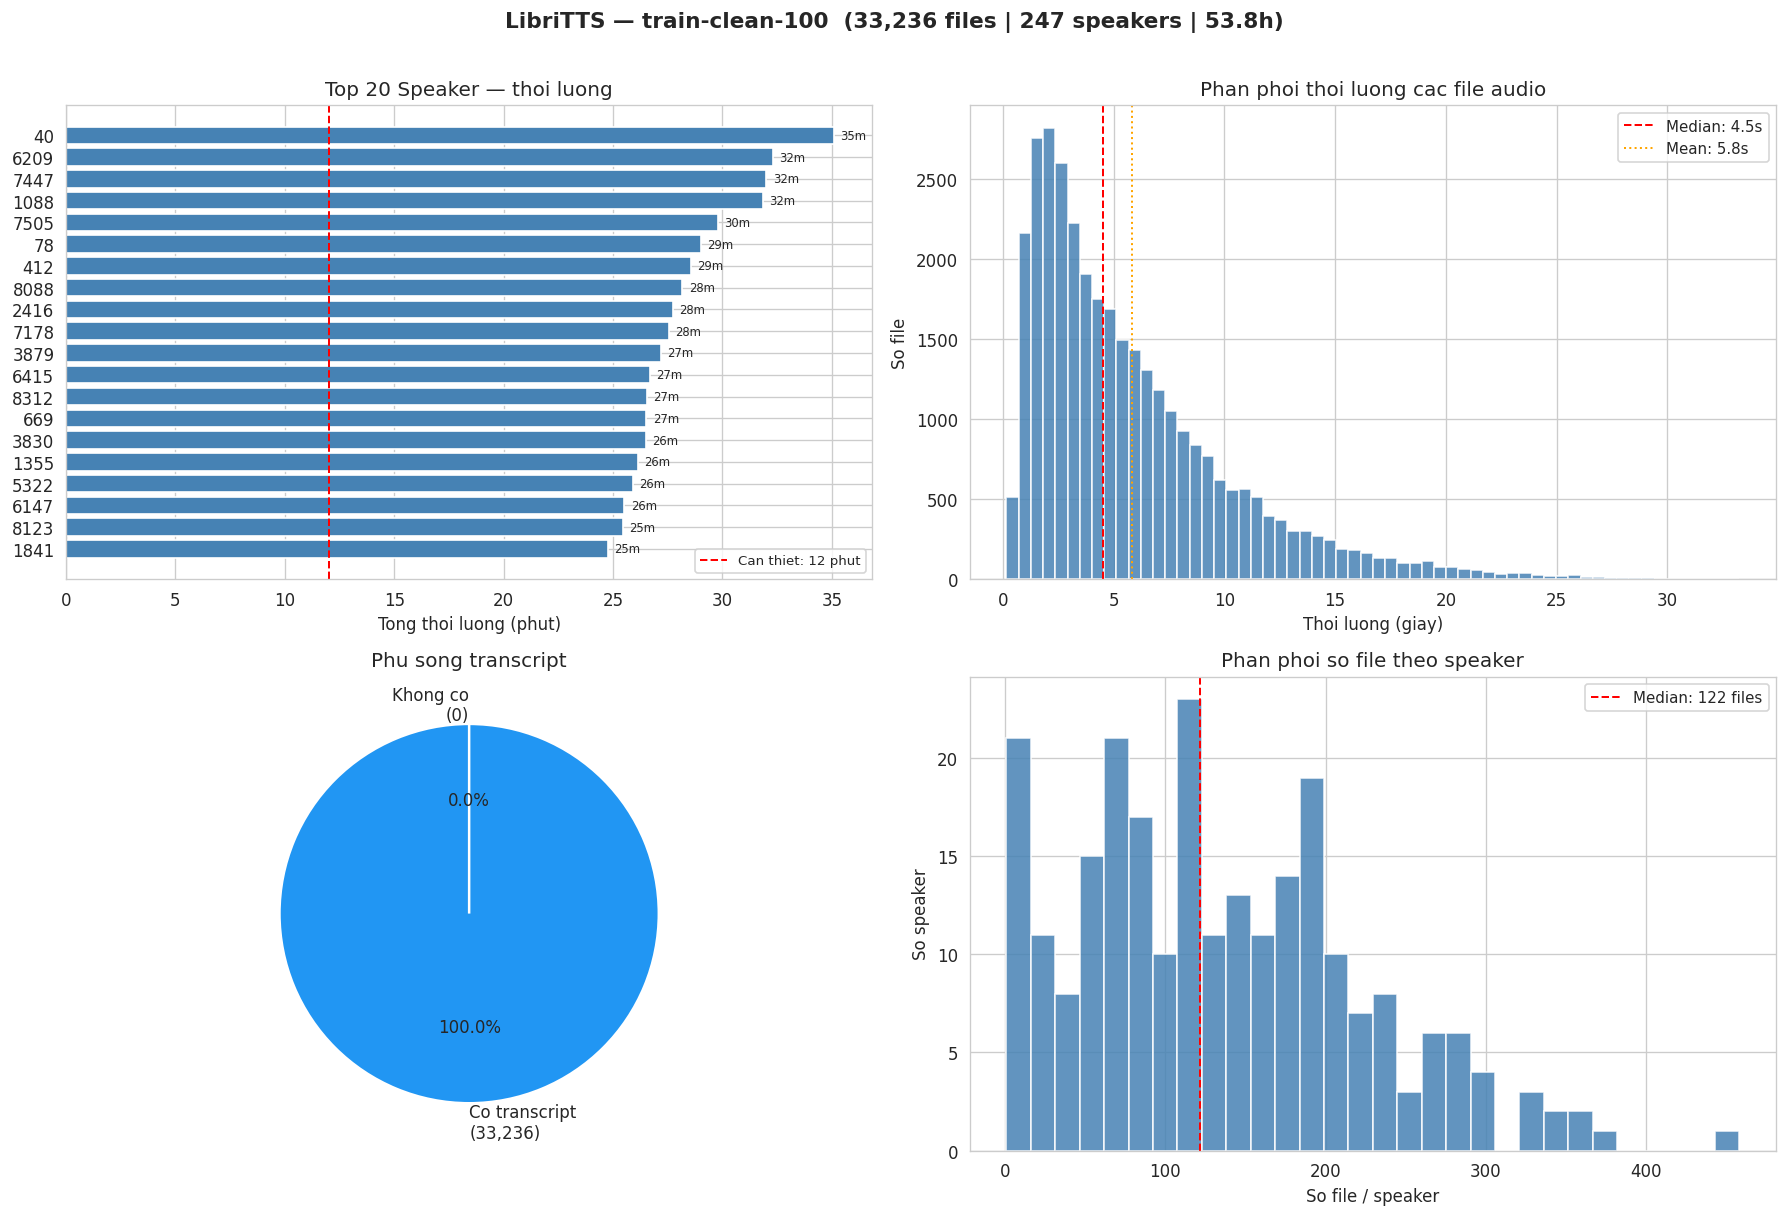

Luu: /content/drive/MyDrive/rvc_project/eval_project/results/viz_train-clean-100_overview.png

Speakers du 12 phut: 132 / 247
Duration  — min: 0.2s | max: 33.2s | median: 4.5s


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'LibriTTS — {TARGET_SPLIT}  ({train_df.shape[0]:,} files | {len(train_spk)} speakers | {train_df["duration_sec"].sum()/3600:.1f}h)',
             fontsize=13, fontweight='bold', y=1.01)

# --- 1. Top 20 speakers by duration ---
ax = axes[0, 0]
top20 = train_spk.head(20).iloc[::-1]
bars = ax.barh(top20['speaker_id'].astype(str), top20['total_min'], color='steelblue', edgecolor='white')
ax.set_xlabel('Tong thoi luong (phut)')
ax.set_title('Top 20 Speaker — thoi luong')
needed_min = (TARGET_TRAIN_SECONDS + TARGET_EVAL_SECONDS) / 60
ax.axvline(needed_min, color='red', linestyle='--', linewidth=1.2, label=f'Can thiet: {needed_min:.0f} phut')
ax.legend(fontsize=8)
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.0f}m', va='center', fontsize=7)

# --- 2. Utterance duration distribution ---
ax = axes[0, 1]
durs = train_df['duration_sec'].dropna()
ax.hist(durs, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
med = durs.median()
ax.axvline(med, color='red', linestyle='--', linewidth=1.2, label=f'Median: {med:.1f}s')
ax.axvline(durs.mean(), color='orange', linestyle=':', linewidth=1.2, label=f'Mean: {durs.mean():.1f}s')
ax.set_xlabel('Thoi luong (giay)')
ax.set_ylabel('So file')
ax.set_title('Phan phoi thoi luong cac file audio')
ax.legend(fontsize=9)

# --- 3. Transcript coverage ---
ax = axes[1, 0]
has_tx = train_df['transcript'].astype(str).str.strip().str.len() > 0
vals   = [has_tx.sum(), (~has_tx).sum()]
labels = [f'Co transcript\n({vals[0]:,})', f'Khong co\n({vals[1]:,})']
wedges, texts, autotexts = ax.pie(vals, labels=labels, autopct='%1.1f%%',
                                   colors=['#2196F3', '#EF5350'], startangle=90,
                                   wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Phu song transcript')

# --- 4. Files per speaker distribution ---
ax = axes[1, 1]
ax.hist(train_spk['n_files'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
med_f = train_spk['n_files'].median()
ax.axvline(med_f, color='red', linestyle='--', linewidth=1.2, label=f'Median: {med_f:.0f} files')
ax.set_xlabel('So file / speaker')
ax.set_ylabel('So speaker')
ax.set_title('Phan phoi so file theo speaker')
ax.legend(fontsize=9)

plt.tight_layout()
out_path = RESULTS_DIR / f'viz_{TARGET_SPLIT}_overview.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Luu: {out_path}')

# In thong ke nhanh
print(f'\nSpeakers du {needed_min:.0f} phut: {(train_spk["total_min"] >= needed_min).sum()} / {len(train_spk)}')
print(f'Duration  — min: {durs.min():.1f}s | max: {durs.max():.1f}s | median: {durs.median():.1f}s')

## Cell 12 — Trực quan hóa: Source Split (`test-clean`)

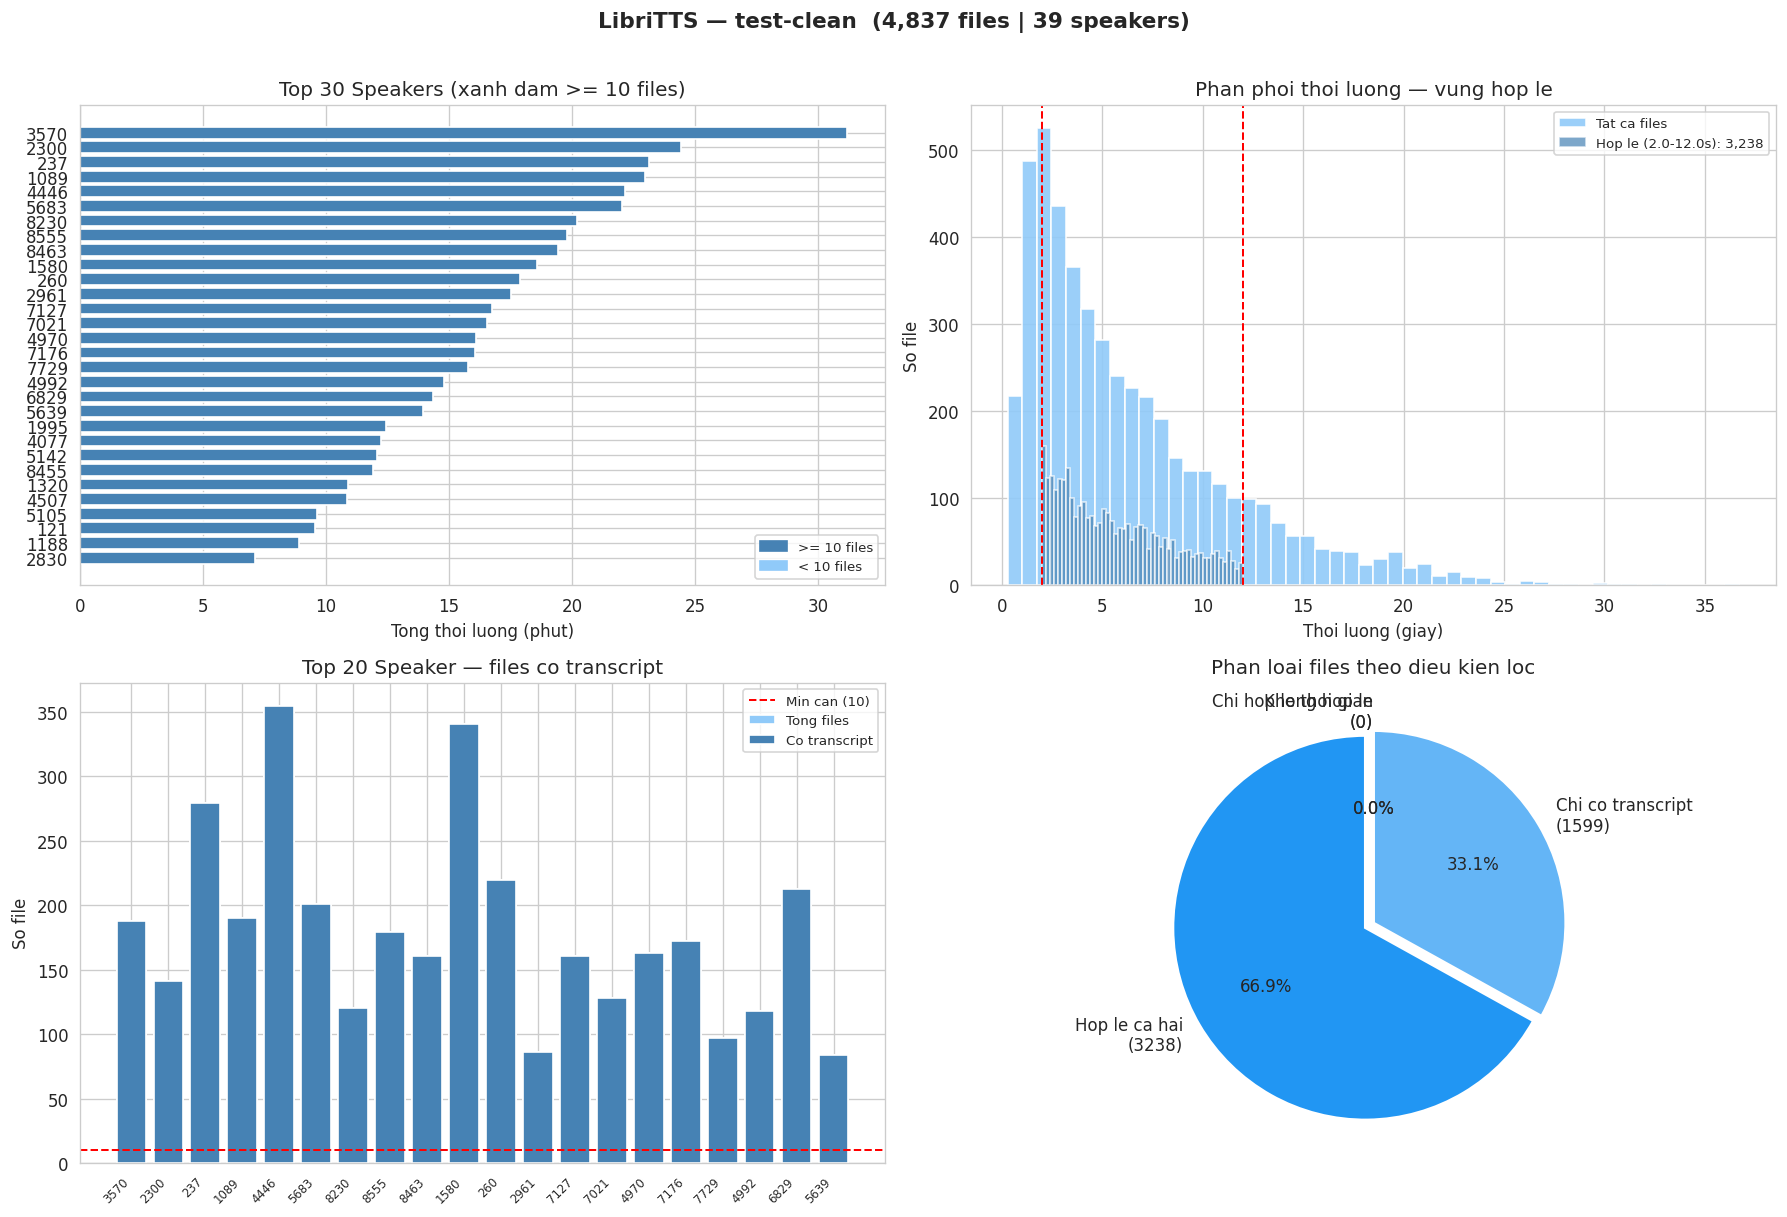

Luu: /content/drive/MyDrive/rvc_project/eval_project/results/viz_test-clean_overview.png

Files hop le (co transcript + 2.0-12.0s): 3,238 / 4,837
Speakers co >= 10 files hop le: 36


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'LibriTTS — {SOURCE_SPLIT}  ({source_df.shape[0]:,} files | {len(source_spk)} speakers)',
             fontsize=13, fontweight='bold', y=1.01)

# --- 1. Speaker duration (all speakers) ---
ax = axes[0, 0]
top_src = source_spk.head(30).iloc[::-1]
colors  = ['steelblue' if n >= SOURCE_TEST_COUNT else '#90CAF9' for n in top_src['n_files']]
ax.barh(top_src['speaker_id'].astype(str), top_src['total_min'], color=colors, edgecolor='white')
ax.set_xlabel('Tong thoi luong (phut)')
ax.set_title(f'Top 30 Speakers (xanh dam >= {SOURCE_TEST_COUNT} files)')
rich = mpatches.Patch(color='steelblue', label=f'>= {SOURCE_TEST_COUNT} files')
poor = mpatches.Patch(color='#90CAF9', label=f'< {SOURCE_TEST_COUNT} files')
ax.legend(handles=[rich, poor], fontsize=8)

# --- 2. Duration distribution with valid range highlighted ---
ax = axes[0, 1]
sdurs = source_df['duration_sec'].dropna()
ax.hist(sdurs, bins=50, color='#90CAF9', edgecolor='white', alpha=0.9, label='Tat ca files')
valid = sdurs[(sdurs >= MIN_SOURCE_DURATION) & (sdurs <= MAX_SOURCE_DURATION)]
ax.hist(valid, bins=50, color='steelblue', edgecolor='white', alpha=0.7,
        label=f'Hop le ({MIN_SOURCE_DURATION}-{MAX_SOURCE_DURATION}s): {len(valid):,}')
ax.axvline(MIN_SOURCE_DURATION, color='red', linestyle='--', linewidth=1.2)
ax.axvline(MAX_SOURCE_DURATION, color='red', linestyle='--', linewidth=1.2)
ax.set_xlabel('Thoi luong (giay)')
ax.set_ylabel('So file')
ax.set_title(f'Phan phoi thoi luong — vung hop le')
ax.legend(fontsize=8)

# --- 3. Files with transcript per speaker (top 20) ---
ax = axes[1, 0]
top20_src = source_spk.head(20).copy()
x = range(len(top20_src))
ax.bar(x, top20_src['n_files'],          color='#90CAF9', label='Tong files', edgecolor='white')
ax.bar(x, top20_src['n_with_transcript'], color='steelblue', label='Co transcript', edgecolor='white')
ax.set_xticks(list(x))
ax.set_xticklabels(top20_src['speaker_id'].astype(str), rotation=45, ha='right', fontsize=7)
ax.set_ylabel('So file')
ax.set_title('Top 20 Speaker — files co transcript')
ax.axhline(SOURCE_TEST_COUNT, color='red', linestyle='--', linewidth=1.2,
           label=f'Min can ({SOURCE_TEST_COUNT})')
ax.legend(fontsize=8)

# --- 4. Valid vs invalid files (duration filter) ---
ax = axes[1, 1]
has_tx_src   = source_df['transcript'].astype(str).str.strip().str.len() > 0
in_range     = source_df['duration_sec'].between(MIN_SOURCE_DURATION, MAX_SOURCE_DURATION)
both_ok      = has_tx_src & in_range
only_tx      = has_tx_src & ~in_range
only_range   = ~has_tx_src & in_range
neither      = ~has_tx_src & ~in_range
sizes  = [both_ok.sum(), only_tx.sum(), only_range.sum(), neither.sum()]
labels = [f'Hop le ca hai\n({both_ok.sum()})',
          f'Chi co transcript\n({only_tx.sum()})',
          f'Chi hop le thoi gian\n({only_range.sum()})',
          f'Khong hop le\n({neither.sum()})']
colors_pie = ['#2196F3', '#64B5F6', '#FFA726', '#EF5350']
explode    = (0.05, 0, 0, 0)
ax.pie([s if s > 0 else 0.0001 for s in sizes], labels=labels, colors=colors_pie,
       autopct='%1.1f%%', startangle=90, explode=explode,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title(f'Phan loai files theo dieu kien loc')

plt.tight_layout()
out_path = RESULTS_DIR / f'viz_{SOURCE_SPLIT}_overview.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Luu: {out_path}')

print(f'\nFiles hop le (co transcript + {MIN_SOURCE_DURATION}-{MAX_SOURCE_DURATION}s): {both_ok.sum():,} / {len(source_df):,}')
print(f'Speakers co >= {SOURCE_TEST_COUNT} files hop le: {(source_spk["n_files"] >= SOURCE_TEST_COUNT).sum()}')

## Cell 13 — Chuẩn bị dữ liệu Audio

In [22]:
manifests_exist = all([
    (PREPARED_DIR / 'target_train_manifest.csv').exists(),
    (PREPARED_DIR / 'target_eval_manifest.csv').exists(),
    (PREPARED_DIR / 'source_test_manifest.csv').exists(),
])

if manifests_exist and not RESET_PREPARED_DATA:
    print('Da co prepared_data — bo qua (dat RESET_PREPARED_DATA=True de tao lai)')
else:
    if RESET_PREPARED_DATA and PREPARED_DIR.exists():
        shutil.rmtree(PREPARED_DIR)
    PREPARED_DIR.mkdir(parents=True, exist_ok=True)

    needed = TARGET_TRAIN_SECONDS + TARGET_EVAL_SECONDS

    _target_id = TARGET_SPEAKER_ID
    if _target_id is None:
        cands = train_spk[train_spk['total_sec'] >= needed]
        if cands.empty:
            raise ValueError(f'Khong co speaker du {needed/60:.1f} phut. Giam TARGET_TRAIN/EVAL_SECONDS.')
        _target_id = str(cands.iloc[0]['speaker_id'])

    _source_id = SOURCE_SPEAKER_ID
    if _source_id is None:
        valid_mask = (
            source_df['transcript'].astype(str).str.strip().str.len() > 0
        ) & source_df['duration_sec'].between(MIN_SOURCE_DURATION, MAX_SOURCE_DURATION)
        valid_src = source_df[valid_mask].copy()
        src_counts = valid_src.groupby('speaker_id').size().reset_index(name='n_valid')
        cands = src_counts[
            (src_counts['n_valid'] >= SOURCE_TEST_COUNT) &
            (src_counts['speaker_id'].astype(str) != str(_target_id))
        ]
        if cands.empty:
            cands = src_counts[src_counts['n_valid'] >= SOURCE_TEST_COUNT]
        if cands.empty:
            raise ValueError(f'Khong co source speaker du {SOURCE_TEST_COUNT} files hop le.')
        _source_id = str(cands.iloc[0]['speaker_id'])

    print(f'Target speaker : {_target_id}')
    print(f'Source speaker : {_source_id}')

    target_all = (
        train_df[train_df['speaker_id'].astype(str) == str(_target_id)]
        .dropna(subset=['duration_sec'])
        .pipe(lambda d: d[d['duration_sec'] > 0])
        .sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    )

    train_rows, eval_rows, used, acc = [], [], set(), 0.0
    for i, row in target_all.iterrows():
        if acc < TARGET_TRAIN_SECONDS:
            train_rows.append(row); used.add(i); acc += float(row['duration_sec'])
    acc_eval = 0.0
    for i, row in target_all.iterrows():
        if i not in used and acc_eval < TARGET_EVAL_SECONDS:
            eval_rows.append(row); acc_eval += float(row['duration_sec'])

    src_pool = source_df[
        (source_df['speaker_id'].astype(str) == str(_source_id)) &
        (source_df['transcript'].astype(str).str.strip().str.len() > 0) &
        (source_df['duration_sec'].between(MIN_SOURCE_DURATION, MAX_SOURCE_DURATION))
    ].copy()
    if len(src_pool) < SOURCE_TEST_COUNT:
        src_pool = source_df[
            (source_df['speaker_id'].astype(str) == str(_source_id)) &
            (source_df['transcript'].astype(str).str.strip().str.len() > 0)
        ].copy()
    src_sel = src_pool.sample(n=min(SOURCE_TEST_COUNT, len(src_pool)),
                               random_state=RANDOM_SEED).reset_index(drop=True)

    tt = prepare_audio_set(pd.DataFrame(train_rows), PREPARED_DIR / 'target_train',
                           'target_train', PREPARED_AUDIO_SR)
    te = prepare_audio_set(pd.DataFrame(eval_rows),  PREPARED_DIR / 'target_eval',
                           'target_eval',  PREPARED_AUDIO_SR)
    st = prepare_audio_set(src_sel,                  PREPARED_DIR / 'source_test',
                           'source',       PREPARED_AUDIO_SR)

    tt.to_csv(PREPARED_DIR / 'target_train_manifest.csv', index=False, encoding='utf-8-sig')
    te.to_csv(PREPARED_DIR / 'target_eval_manifest.csv',  index=False, encoding='utf-8-sig')
    st.to_csv(PREPARED_DIR / 'source_test_manifest.csv',  index=False, encoding='utf-8-sig')
    st[['file', 'transcript']].to_csv(PREPARED_DIR / 'transcript.csv', index=False, encoding='utf-8-sig')

    print(f'\nTarget train : {tt["duration_sec"].sum()/60:.1f} phut ({len(tt)} files)')
    print(f'Target eval  : {te["duration_sec"].sum()/60:.1f} phut ({len(te)} files)')
    print(f'Source test  : {len(st)} files')
    print(f'Luu tai: {PREPARED_DIR}')

Target speaker : 40
Source speaker : 1089


Prepare target_train:   0%|          | 0/94 [00:00<?, ?it/s]

Prepare target_eval:   0%|          | 0/20 [00:00<?, ?it/s]

Prepare source:   0%|          | 0/10 [00:00<?, ?it/s]


Target train : 10.1 phut (94 files)
Target eval  : 2.1 phut (20 files)
Source test  : 10 files
Luu tai: /content/drive/MyDrive/rvc_project/eval_project/prepared_data


## Cell 14 — Trực quan hóa: Dữ liệu đã chuẩn bị

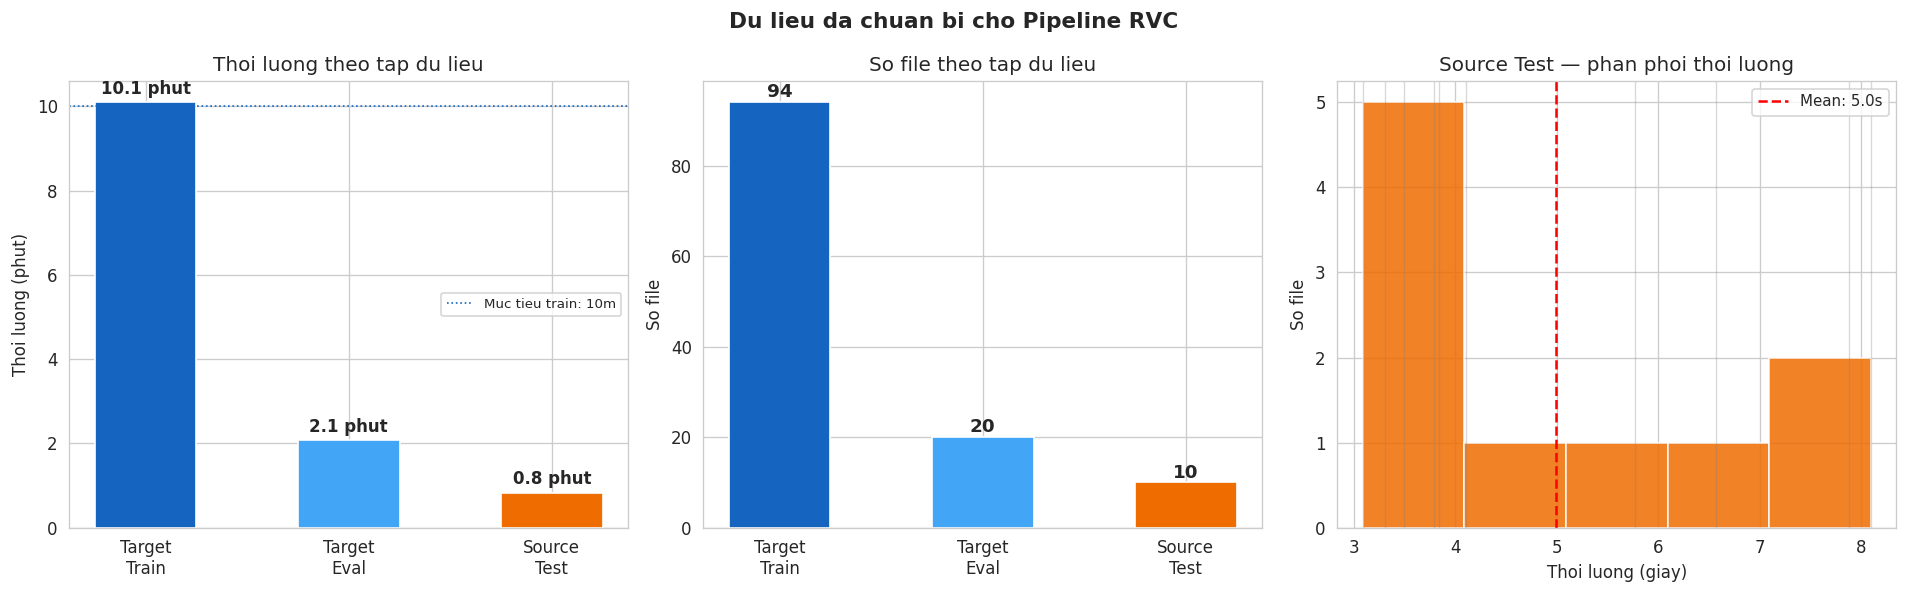

Luu: /content/drive/MyDrive/rvc_project/eval_project/results/viz_prepared_data_overview.png


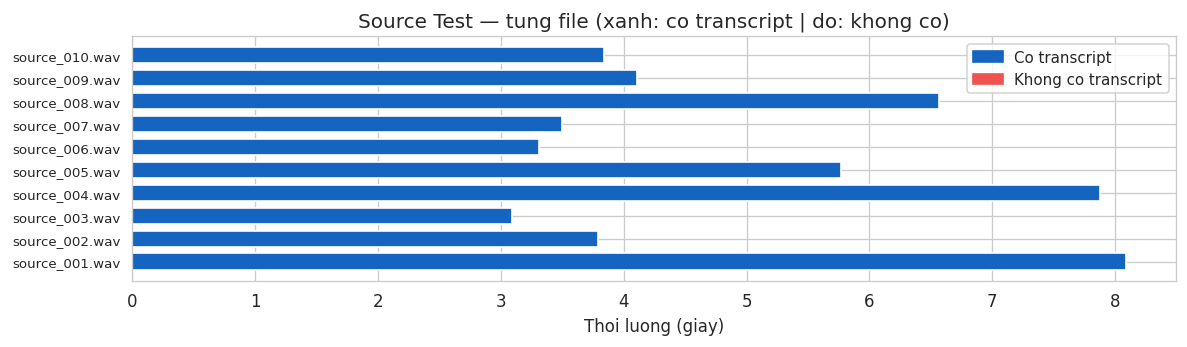

Luu: /content/drive/MyDrive/rvc_project/eval_project/results/viz_source_test_files.png


In [23]:
tt_m = pd.read_csv(PREPARED_DIR / 'target_train_manifest.csv')
te_m = pd.read_csv(PREPARED_DIR / 'target_eval_manifest.csv')
st_m = pd.read_csv(PREPARED_DIR / 'source_test_manifest.csv')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Du lieu da chuan bi cho Pipeline RVC', fontsize=13, fontweight='bold')

# --- 1. Duration comparison (bar) ---
ax = axes[0]
labels_bar  = ['Target\nTrain', 'Target\nEval', 'Source\nTest']
durations   = [
    tt_m['duration_sec'].sum() / 60,
    te_m['duration_sec'].sum() / 60,
    st_m['duration_sec'].sum() / 60,
]
colors_bar  = ['#1565C0', '#42A5F5', '#EF6C00']
bars = ax.bar(labels_bar, durations, color=colors_bar, edgecolor='white', width=0.5)
for bar, val in zip(bars, durations):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{val:.1f} phut', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Thoi luong (phut)')
ax.set_title('Thoi luong theo tap du lieu')
ax.axhline(TARGET_TRAIN_SECONDS / 60, color='#1565C0', linestyle=':', linewidth=1,
           label=f'Muc tieu train: {TARGET_TRAIN_SECONDS/60:.0f}m')
ax.legend(fontsize=8)

# --- 2. File count comparison ---
ax = axes[1]
counts = [len(tt_m), len(te_m), len(st_m)]
bars2  = ax.bar(labels_bar, counts, color=colors_bar, edgecolor='white', width=0.5)
for bar, val in zip(bars2, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('So file')
ax.set_title('So file theo tap du lieu')

# --- 3. Source test: duration distribution ---
ax = axes[2]
src_durs = st_m['duration_sec'].dropna()
ax.hist(src_durs, bins=max(5, len(src_durs)//2), color='#EF6C00', edgecolor='white', alpha=0.85)
ax.axvline(src_durs.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {src_durs.mean():.1f}s')
for i, (_, row) in enumerate(st_m.iterrows()):
    ax.axvline(row['duration_sec'], color='gray', alpha=0.3, linewidth=0.8)
ax.set_xlabel('Thoi luong (giay)')
ax.set_ylabel('So file')
ax.set_title('Source Test — phan phoi thoi luong')
ax.legend(fontsize=9)

plt.tight_layout()
out_path = RESULTS_DIR / 'viz_prepared_data_overview.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Luu: {out_path}')

# --- Transcript coverage for source test ---
fig2, ax2 = plt.subplots(1, 1, figsize=(10, 3))
has_tx = st_m['transcript'].astype(str).str.strip().str.len() > 0
y_pos  = range(len(st_m))
colors_bar2 = ['#1565C0' if v else '#EF5350' for v in has_tx]
bars3 = ax2.barh(y_pos, st_m['duration_sec'], color=colors_bar2, edgecolor='white', height=0.7)
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(st_m['file'].tolist(), fontsize=8)
ax2.set_xlabel('Thoi luong (giay)')
ax2.set_title('Source Test — tung file (xanh: co transcript | do: khong co)')
tx_patch  = mpatches.Patch(color='#1565C0', label='Co transcript')
notx_patch = mpatches.Patch(color='#EF5350', label='Khong co transcript')
ax2.legend(handles=[tx_patch, notx_patch], fontsize=9)
plt.tight_layout()
out_path2 = RESULTS_DIR / 'viz_source_test_files.png'
plt.savefig(out_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Luu: {out_path2}')

## Cell 15 — Tổng kết: Dữ liệu sẵn sàng cho pipeline

TONG KET — DU LIEU SAN SANG CHO PIPELINE RVC


,Trang thai,So file,Thoi luong (phut),Co transcript,Ghi chu
Tap du lieu,,,,,
Target Train,SAN SANG,94,10.1,94/94,(muc tieu: 10 phut)
Target Eval,SAN SANG,20,2.1,20/20,(muc tieu: 2 phut)
Source Test,SAN SANG,10,0.8,10/10,



[RVC Weights]
  HuBERT               SAN SANG  (181 MB)
  RMVPE                SAN SANG  (173 MB)
  Pretrained G         SAN SANG  (70 MB)
  Pretrained D         SAN SANG  (136 MB)

DU LIEU SAN SANG HOAN TOAN!
-> Chay notebook RVC_pipeline_colab.ipynb de bat dau training


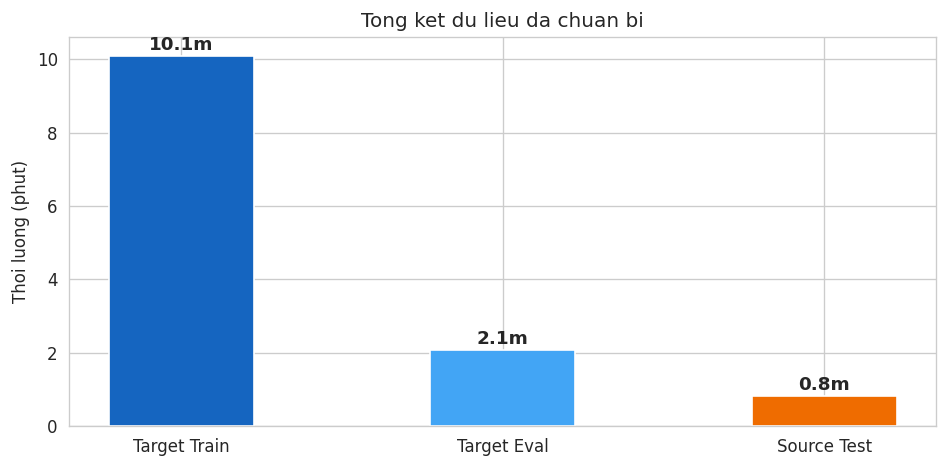


Luu: /content/drive/MyDrive/rvc_project/eval_project/results/viz_final_summary.png


In [24]:
print('=' * 65)
print('TONG KET — DU LIEU SAN SANG CHO PIPELINE RVC')
print('=' * 65)

# --- Manifests ---
rows = []
for label, fname, target_sec in [
    ('Target Train', 'target_train_manifest.csv', TARGET_TRAIN_SECONDS),
    ('Target Eval',  'target_eval_manifest.csv',  TARGET_EVAL_SECONDS),
    ('Source Test',  'source_test_manifest.csv',  None),
]:
    p = PREPARED_DIR / fname
    if p.exists():
        df_m = pd.read_csv(p)
        dur  = df_m['duration_sec'].sum() if 'duration_sec' in df_m.columns else 0
        tx_ok = (df_m['transcript'].astype(str).str.strip().str.len() > 0).sum() if 'transcript' in df_m.columns else 0
        target_str = f'(muc tieu: {target_sec/60:.0f} phut)' if target_sec else ''
        status = 'SAN SANG'
        rows.append({'Tap du lieu': label, 'Trang thai': status,
                     'So file': len(df_m), 'Thoi luong (phut)': f'{dur/60:.1f}',
                     'Co transcript': f'{tx_ok}/{len(df_m)}', 'Ghi chu': target_str})
    else:
        rows.append({'Tap du lieu': label, 'Trang thai': 'CHUA CO',
                     'So file': 0, 'Thoi luong (phut)': '0',
                     'Co transcript': '—', 'Ghi chu': 'Chay Cell 13'})

summary_df = pd.DataFrame(rows)
try:
    display(summary_df.set_index('Tap du lieu'))
except NameError:
    print(summary_df.to_string(index=False))

# --- Weights ---
print('\n[RVC Weights]')
REPO_DIR = '/content/compare_rvc'
weight_paths = [
    ('HuBERT',       f'{REPO_DIR}/assets/hubert/hubert_base.pt'),
    ('RMVPE',        f'{REPO_DIR}/assets/rmvpe/rmvpe.pt'),
    ('Pretrained G', f'{REPO_DIR}/assets/pretrained_v2/f0G40k.pth'),
    ('Pretrained D', f'{REPO_DIR}/assets/pretrained_v2/f0D40k.pth'),
]
all_weights_ok = True
for name, path in weight_paths:
    p = Path(path)
    if p.exists() and p.stat().st_size > 1_000_000:
        print(f'  {name:<20} SAN SANG  ({p.stat().st_size/1024**2:.0f} MB)')
    else:
        print(f'  {name:<20} CHUA CO   -> Chay Cell 8')
        all_weights_ok = False

# --- Ket luan ---
all_prepared = all(r['Trang thai'] == 'SAN SANG' for r in rows)
print('\n' + '=' * 65)
if all_prepared and all_weights_ok:
    print('DU LIEU SAN SANG HOAN TOAN!')
    print('-> Chay notebook RVC_pipeline_colab.ipynb de bat dau training')
else:
    if not all_prepared:    print('  -> Mot so tap du lieu chua co — chay Cell 13')
    if not all_weights_ok:  print('  -> Mot so weights chua co — chay Cell 8')

# --- Bieu do tong ket (neu du data) ---
if all_prepared:
    fig, ax = plt.subplots(figsize=(8, 4))
    datasets  = ['Target Train', 'Target Eval', 'Source Test']
    durations = [
        pd.read_csv(PREPARED_DIR / 'target_train_manifest.csv')['duration_sec'].sum() / 60,
        pd.read_csv(PREPARED_DIR / 'target_eval_manifest.csv')['duration_sec'].sum() / 60,
        pd.read_csv(PREPARED_DIR / 'source_test_manifest.csv')['duration_sec'].sum() / 60,
    ]
    colors_f = ['#1565C0', '#42A5F5', '#EF6C00']
    bars = ax.bar(datasets, durations, color=colors_f, edgecolor='white', width=0.45)
    for bar, val in zip(bars, durations):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f'{val:.1f}m', ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_ylabel('Thoi luong (phut)')
    ax.set_title('Tong ket du lieu da chuan bi')
    plt.tight_layout()
    out_f = RESULTS_DIR / 'viz_final_summary.png'
    plt.savefig(out_f, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nLuu: {out_f}')